In [1]:
# Replace with your file path
file_path = 'https://tayweid.github.io/econ-0150/data/'
#file_path = 'drive/MyDrive/TEACHING/ECON_0150/Part_6/'

# Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn   as sns
import sys


# Research Question

*Do counties with higher unemployment vote at higher rates?*


### Load Elections Data

*Data collected from electionlab.mit.edu*.

In [2]:
elections = pd.read_csv(file_path + 'countypres_2000-2020.csv')

# Drop empty rows
elections = elections.dropna()

# Set FIPS as index
elections.index = elections.county_fips.astype(int).astype(str)

# Print header
elections.head()

,year,state,state_po,county_name,county_fips,office,candidate,party,candidatevotes,totalvotes,version,mode
county_fips,,,,,,,,,,,,
1001,2000,ALABAMA,AL,AUTAUGA,1001.0,US PRESIDENT,AL GORE,DEMOCRAT,4942,17208,20220315,TOTAL
1001,2000,ALABAMA,AL,AUTAUGA,1001.0,US PRESIDENT,GEORGE W. BUSH,REPUBLICAN,11993,17208,20220315,TOTAL
1001,2000,ALABAMA,AL,AUTAUGA,1001.0,US PRESIDENT,RALPH NADER,GREEN,160,17208,20220315,TOTAL
1001,2000,ALABAMA,AL,AUTAUGA,1001.0,US PRESIDENT,OTHER,OTHER,113,17208,20220315,TOTAL
1003,2000,ALABAMA,AL,BALDWIN,1003.0,US PRESIDENT,AL GORE,DEMOCRAT,13997,56480,20220315,TOTAL


### Load Census Data

*Data collected from the Census via IPUMS.*

In [ ]:
#df = pd.read_csv(file_path + 'usa_00043_formatted.csv', index_col=0)

# Drop nan values
#df = df[~df.COUNTYFIP.isna()]

# Construct county_fips: STATEFIP + COUNTYFIP with STATEFIP
#df['county_fips'] = df.STATEFIP.astype(int).astype(str) + df.COUNTYFIP.astype(int).astype(str).str.zfill(3)

# Create indicator variable for unemployed
#df['unemployed'] = (df['EMPSTAT'] == 2)*1

# Drop N/A or unknown
#df = df[df['INCTOT'] < 9999998]

# Summarize average SEX, AGE, EMPSTATD, and INCTOT by county_fips
#county = df.groupby(['county_fips', 'YEAR'])[['SEX', 'AGE', 'unemployed']].mean()

# Define unemployed as percentage points
#county['unemployed'] = county['unemployed'] * 100

# Get median income by county
#county['med_inc'] = df.groupby(['county_fips', 'YEAR'])[['INCTOT']].median()

# Get population by county
#county['pop'] = df.groupby(['county_fips', 'YEAR'])[['PERWT']].sum()

# Set index as year
#county = county.reset_index(level='YEAR')

# Save a copy of this data
#county.to_csv(local_file_path + 'usa_00043_county.csv')

In [3]:
county = pd.read_csv(file_path + 'usa_00043_county.csv', index_col=0)
county.head()

,YEAR,SEX,AGE,unemployed,med_inc,pop
county_fips,,,,,,
1000,2007,1.528807,48.180949,3.290372,17000.0,2149584.0
1000,2011,1.522652,48.966183,5.713311,15800.0,2250941.0
1000,2015,1.523972,49.649278,3.608744,18000.0,2438898.0
1000,2019,1.524781,50.154590,2.279030,21555.0,2464639.0
10001,2007,1.535065,45.457143,2.943723,22300.0,124513.0


### Combine Census and Elections Data

In [4]:
# Filter to 2012 election, one row per county (total votes only)
e2012 = elections[(elections.year == 2012) & (elections['mode'] == 'TOTAL')]
e2012 = e2012.groupby(e2012.county_fips.astype(int).astype(str)).first()

# Filter census to 2011
c2011 = county[county.YEAR == 2011].copy()
c2011.index = c2011.index.astype(int).astype(str)

In [5]:
# Filter elections to 2008 and 2012, one row per county
e2008 = elections[(elections.year == 2008) & (elections['mode'] == 'TOTAL')]
e2008 = e2008.groupby(e2008.county_fips.astype(int).astype(str)).first()

# Filter census to 2007 and 2011
c2007 = county[county.YEAR == 2007].copy()
c2007.index = c2007.index.astype(int).astype(str)

*Cross-sectional dataset: 2012 election + 2011 census*

In [6]:
# Merge and compute turnout
cross_2012 = e2012.merge(c2011, left_index=True, right_index=True)
cross_2012['turnout'] = 100 * cross_2012['totalvotes'] / cross_2012['pop']

*Differenced dataset: 2008 to 2012 changes*

In [7]:
# Merge elections across years
e_diff = e2008[['totalvotes']].merge(e2012[['totalvotes']], left_index=True, right_index=True, suffixes=('_2008', '_2012'))

# Merge census across years
c_diff = c2007[['unemployed', 'med_inc', 'pop']].merge(c2011[['unemployed', 'med_inc', 'pop']], left_index=True, right_index=True, suffixes=('_2007', '_2011'))

# Combine elections and census
diff_2012 = e_diff.merge(c_diff, left_index=True, right_index=True)

# Compute changes
diff_2012['turnout_2008'] = 100 * diff_2012['totalvotes_2008'] / diff_2012['pop_2007']
diff_2012['turnout_2012'] = 100 * diff_2012['totalvotes_2012'] / diff_2012['pop_2011']
diff_2012['delta_turnout'] = diff_2012['turnout_2012'] - diff_2012['turnout_2008']
diff_2012['delta_unemployed'] = diff_2012['unemployed_2011'] - diff_2012['unemployed_2007']
diff_2012['delta_med_inc'] = diff_2012['med_inc_2011'] - diff_2012['med_inc_2007']


### Question

*Did areas that experienced higher unemployment between 2008 to 2012 also see higher higher voter turnout rates?*


#### Step 1. Start by summarizing the variables.

*For our purposes, the main variables are the change in unemployment and turnout rates.*

Text(0, 0.5, 'Count')

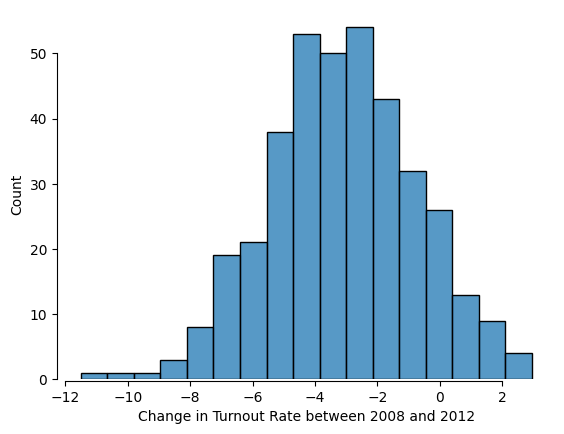

In [8]:
sns.histplot(diff_2012, x='delta_turnout')
plt.xlabel('Change in Turnout Rate between 2008 and 2012')
plt.grid(False)
sns.despine(top=True, right=True, offset=True, trim=True)
plt.ylabel('Count')

Text(0, 0.5, 'Count')

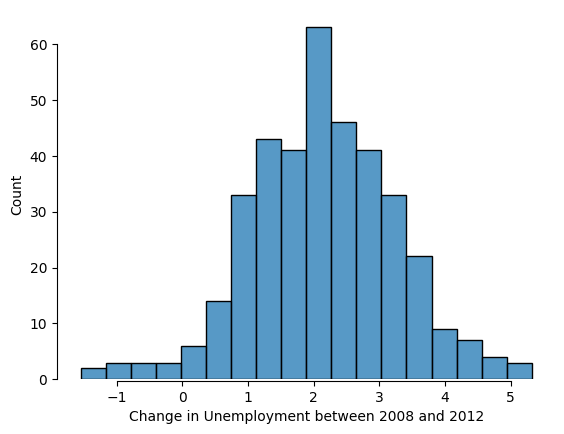

In [9]:
sns.histplot(diff_2012, x='delta_unemployed')
plt.xlabel('Change in Unemployment between 2008 and 2012')
plt.grid(False)
sns.despine(top=True, right=True, offset=True, trim=True)
plt.ylabel('Count')

#### Step 2. Show the main relationship.

*Our main relationship is between the change in unemployment and turnout rates.*

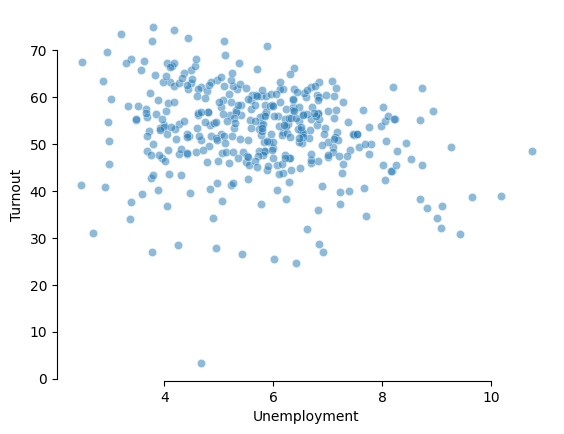

In [10]:
sns.scatterplot(cross_2012, x='unemployed', y='turnout', alpha=0.5)
plt.xlabel('Unemployment')
plt.ylabel('Turnout')
sns.despine(top=True, right=True, offset=True, trim=True)

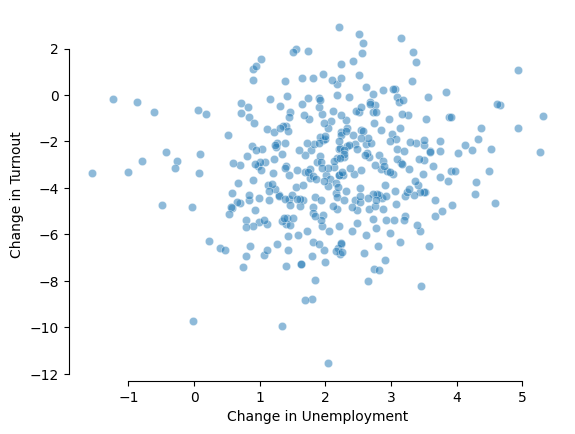

In [11]:
sns.scatterplot(diff_2012, x='delta_unemployed', y='delta_turnout', alpha=0.5)
plt.xlabel('Change in Unemployment')
plt.ylabel('Change in Turnout')
sns.despine(top=True, right=True, offset=True, trim=True)

#### Step 3. Model the relationship:

*Lets run two models. First with levels then one with changes.*

$$\text{turnout} = \beta_0 + \beta_1 \text{unemployed} + \beta_2 \text{med\_inc} + \epsilon$$

$$\Delta\text{turnout} = \beta_0 + \beta_1 \Delta\text{unemployed} + \beta_2 \Delta\text{med\_inc} + \epsilon$$

In [12]:
model1 = smf.ols('turnout ~ unemployed + med_inc', data=cross_2012).fit()
print(model1.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     37.9324      2.977     12.740      0.000      32.078      43.787
unemployed    -0.3327      0.311     -1.068      0.286      -0.945       0.280
med_inc        0.0008    8.6e-05      9.345      0.000       0.001       0.001


In [14]:
model2 = smf.ols('delta_turnout ~ delta_unemployed + delta_med_inc', data=diff_2012).fit()
print(model2.summary().tables[1])

                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -3.5126      0.278    -12.642      0.000      -4.059      -2.966
delta_unemployed     0.2792      0.116      2.406      0.017       0.051       0.507
delta_med_inc     8.476e-05   7.21e-05      1.176      0.240    -5.7e-05       0.000


#### Step 4. Check Residuals

*This isn't a timeseries model so we just need to check the residual plot.*

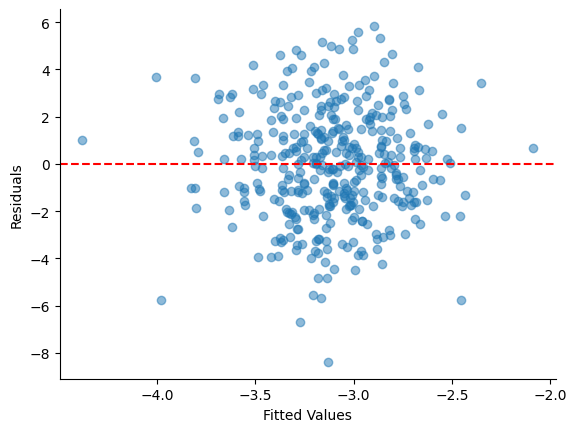

In [15]:
plt.scatter(model2.fittedvalues, model2.resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
sns.despine(top=True, right=True)